
f(x) array:
[0, 0, 0, 1, 0, 0, 0, 0]

 Number of Grover iterations: 2


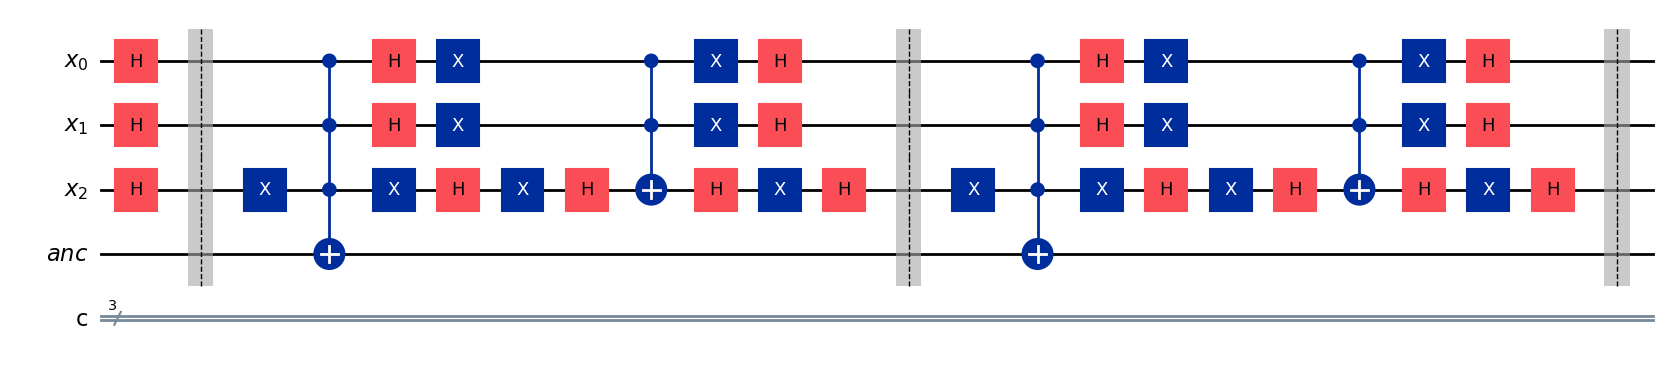


Measurement counts:
{'011': 533, '100': 70, '010': 65, '110': 71, '101': 65, '000': 63, '111': 78, '001': 79}


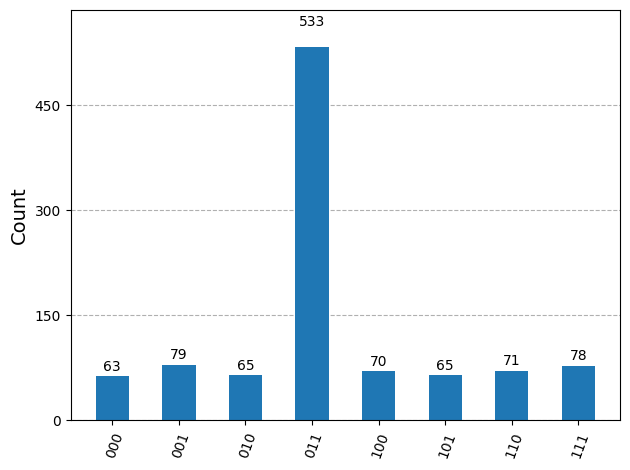


Most measured bitstring = 011
Most measured index = 3

Correct marked positions:
[3]

Success: measured value is one of the indices where f(x)=1.


In [20]:
from qiskit import QuantumRegister, QuantumCircuit, ClassicalRegister
from qiskit.quantum_info import *
from qiskit.visualization import plot_histogram
from IPython.display import display
from qiskit.circuit.library import UnitaryGate
from numpy import pi
from qiskit_aer import AerSimulator
import numpy as np
import math
import random

# User input

N = int(input("Enter total number of values N: "))
M = int(input("Enter number of x values for which f(x)=1: "))

if N <= 0:
    raise ValueError("N must be positive.")

if M <= 0 or M > N:
    raise ValueError("M must satisfy 1 <= M <= N.")


marked_positions = random.sample(range(N), M)

# Make f(x) array

f_array = [0] * N

for pos in marked_positions:
    f_array[pos] = 1

print("\nf(x) array:")
print(f_array)

# Building the ckt

n = math.ceil(math.log2(N))
total_states = 2**n

x = QuantumRegister(n, "x")      
anc = QuantumRegister(1, "anc")   
c = ClassicalRegister(n, "c")     

qc = QuantumCircuit(x, anc, c)

qc.h(range(n))

qc.barrier()

# Number of Grover iterations

r = math.floor((pi / 4) * math.sqrt(N / M))

print("\n Number of Grover iterations:", r)


for iteration in range(r):

    # ---------------- Oracle ----------------
    for index, value in enumerate(f_array):

        if value == 1:
            bitstring = format(index, f"0{n}b")

            for i, bit in enumerate(reversed(bitstring)):
                if bit == "0":
                    qc.x(x[i])

            qc.mcx(x, anc[0])

            for i, bit in enumerate(reversed(bitstring)):
                if bit == "0":
                    qc.x(x[i])


    # ---------------- Diffusion ----------------
    qc.h(x)

    qc.x(x)

    qc.h(x[n-1])
    qc.mcx(x[0:n-1], x[n-1])
    qc.h(x[n-1])

    qc.x(x)

    qc.h(x)

    qc.barrier()

display(qc.draw(output="mpl"))

qc.measure(x, c)

sim = AerSimulator()

result = sim.run(qc, shots=1024).result()
counts = result.get_counts()

print("\nMeasurement counts:")
print(counts)

display(plot_histogram(counts))

measured_bitstring = max(counts, key=counts.get)
measured_index = int(measured_bitstring, 2)

print("\nMost measured bitstring =", measured_bitstring)
print("Most measured index =", measured_index)

print("\nCorrect marked positions:")
print(marked_positions)

if measured_index in marked_positions:
    print("\nSuccess: measured value is one of the indices where f(x)=1.")
else:
    print("\nNot successful this time.")

